# 05 Explainable AI mit SHAP

Ziel dieses Notebooks ist es, die Entscheidungen des trainierten Random-Forest-Modells mithilfe von Explainable AI nachvollziehbar zu machen.

Dabei wird untersucht, welche Netzwerkmerkmale die Klassifikation von Netzwerkverkehr als normal oder als Angriff besonders stark beeinflussen.

## Imports

Für die Explainable-AI-Analyse werden das gespeicherte Modell, der bereinigte Datensatz sowie die Bibliothek SHAP geladen. SHAP wird verwendet, um den Einfluss einzelner Netzwerkmerkmale auf die Modellentscheidung zu erklären.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split

## Pfade definieren

Die Pfade zum bereinigten Datensatz, zum gespeicherten Random-Forest-Modell und zum Ausgabeordner für Visualisierungen werden zentral definiert.

In [2]:
PROCESSED_DATA_PATH = Path("../data/processed")
MODEL_OUTPUT_PATH = Path("../outputs/models")
FIGURE_OUTPUT_PATH = Path("../outputs/figures")

FIGURE_OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

data_file = PROCESSED_DATA_PATH / "cicids2017_friday_binary_clean.csv"
model_file = MODEL_OUTPUT_PATH / "random_forest_cicids2017_binary.joblib"

## Daten und Modell laden

Der bereinigte CICIDS2017-Datensatz und das gespeicherte Random-Forest-Modell werden geladen. Dadurch kann die Explainable-AI-Analyse durchgeführt werden, ohne das Modell erneut trainieren zu müssen.

In [3]:
df = pd.read_csv(data_file)
rf_model = joblib.load(model_file)

print("Datensatz geladen:", df.shape)
print("Modell geladen:", type(rf_model))

Datensatz geladen: (702718, 78)
Modell geladen: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


## Features und Zielvariable trennen

Die Eingabemerkmale `X` enthalten die bereinigten Netzwerkfeatures. Die Zielvariable `y` gibt an, ob ein Netzwerk-Flow normal oder bösartig ist:

- `0` = BENIGN / normaler Netzwerkverkehr
- `1` = Angriff

In [4]:
X = df.drop(columns=["target"])
y = df["target"]

print("Feature-Matrix:", X.shape)
print("Zielvariable:", y.shape)

Feature-Matrix: (702718, 77)
Zielvariable: (702718,)


## Testdaten erzeugen

Für die SHAP-Analyse wird derselbe Testdatensatz wie in der Evaluation verwendet. Dadurch beziehen sich die Erklärungen auf dieselben Daten, auf denen auch die Modellleistung bewertet wurde.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Testdaten:", X_test.shape)
print(y_test.value_counts())

Testdaten: (140544, 77)
target
0    82787
1    57757
Name: count, dtype: int64


## Feature Importance

Die Feature Importance des Random-Forest-Modells zeigt, welche Netzwerkmerkmale insgesamt am stärksten zur Klassifikation beitragen. Sie liefert eine globale Sicht auf die wichtigsten Einflussfaktoren des Modells.

In [6]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance.head(15)

,feature,importance
5,Fwd Packet Length Max,0.116949
7,Fwd Packet Length Mean,0.093223
52,Avg Fwd Segment Size,0.067582
62,Subflow Fwd Bytes,0.048444
65,Init_Win_bytes_forward,0.047451
51,Average Packet Size,0.043205
45,PSH Flag Count,0.039084
3,Total Length of Fwd Packets,0.034787
53,Avg Bwd Segment Size,0.028174
66,Init_Win_bytes_backward,0.027619


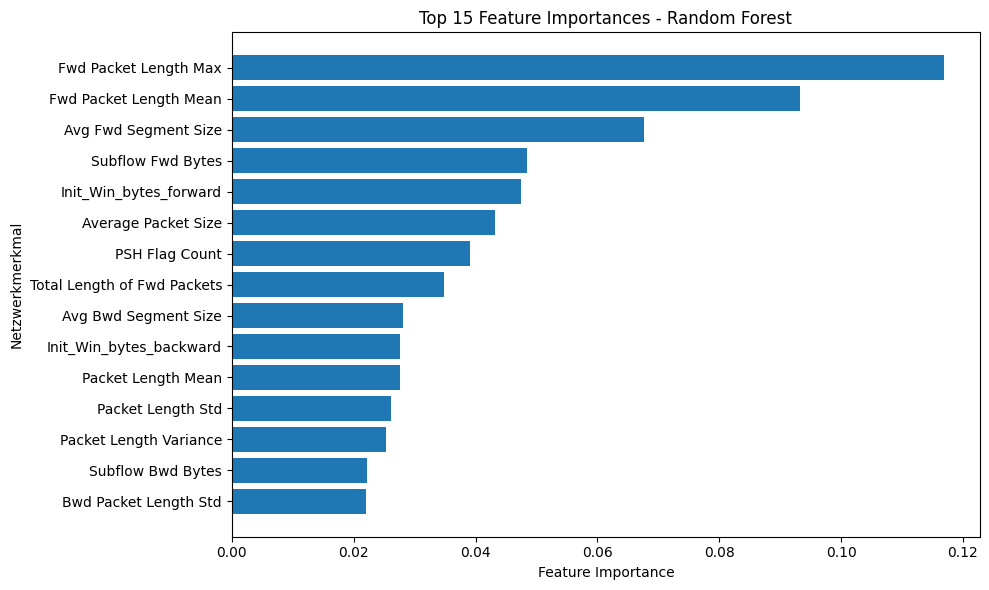

Feature-Importance-Grafik gespeichert unter: ..\outputs\figures\feature_importance_random_forest.png


In [7]:
top_n = 15

plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance.head(top_n)["feature"][::-1],
    feature_importance.head(top_n)["importance"][::-1]
)
plt.xlabel("Feature Importance")
plt.ylabel("Netzwerkmerkmal")
plt.title("Top 15 Feature Importances - Random Forest")
plt.tight_layout()

output_file = FIGURE_OUTPUT_PATH / "feature_importance_random_forest.png"
plt.savefig(output_file, dpi=300)
plt.show()

print(f"Feature-Importance-Grafik gespeichert unter: {output_file}")

Die Visualisierung zeigt die wichtigsten Netzwerkmerkmale des Random-Forest-Modells. Diese Merkmale hatten insgesamt den größten Einfluss auf die Unterscheidung zwischen normalem Netzwerkverkehr und Angriffen.

## Stichprobe für SHAP

Da SHAP-Berechnungen bei großen Datensätzen rechenintensiv sind, wird eine Stichprobe aus den Testdaten verwendet. Diese Stichprobe dient dazu, die Modellentscheidungen effizient und nachvollziehbar zu erklären.

In [8]:
sample_size = 1000

X_test_sample = X_test.sample(
    n=min(sample_size, len(X_test)),
    random_state=42
)

print("SHAP-Stichprobe:", X_test_sample.shape)

SHAP-Stichprobe: (1000, 77)


## SHAP-Werte berechnen

SHAP berechnet für jedes Netzwerkmerkmal, wie stark es die Modellentscheidung beeinflusst. Dadurch wird sichtbar, welche Features eine Entscheidung eher in Richtung normaler Traffic oder Angriff verschieben.

In [9]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_sample)

print("SHAP-Werte berechnet.")

SHAP-Werte berechnet.


## Auswahl der Angriffsklasse

Da das Modell eine binäre Klassifikation durchführt, werden für die Interpretation die SHAP-Werte der Klasse `Angriff` betrachtet. Dadurch wird analysiert, welche Merkmale eine Entscheidung in Richtung Angriff beeinflussen.

In [10]:
# SHAP-Werte für Klasse 1 = Angriff extrahieren

if isinstance(shap_values, list):
    shap_values_attack = shap_values[1]
else:
    # Für neuere SHAP-Versionen kann das Array dreidimensional sein:
    # (Samples, Features, Classes)
    if len(shap_values.shape) == 3:
        shap_values_attack = shap_values[:, :, 1]
    else:
        shap_values_attack = shap_values

print("Form der SHAP-Werte für Angriffsklasse:", shap_values_attack.shape)

Form der SHAP-Werte für Angriffsklasse: (1000, 77)


## SHAP Feature Importance

Der SHAP-Bar-Plot zeigt die durchschnittliche Bedeutung der Netzwerkmerkmale für die Angriffsklasse. Im Gegensatz zur klassischen Feature Importance berücksichtigt SHAP den Beitrag einzelner Merkmale zur Modellentscheidung.

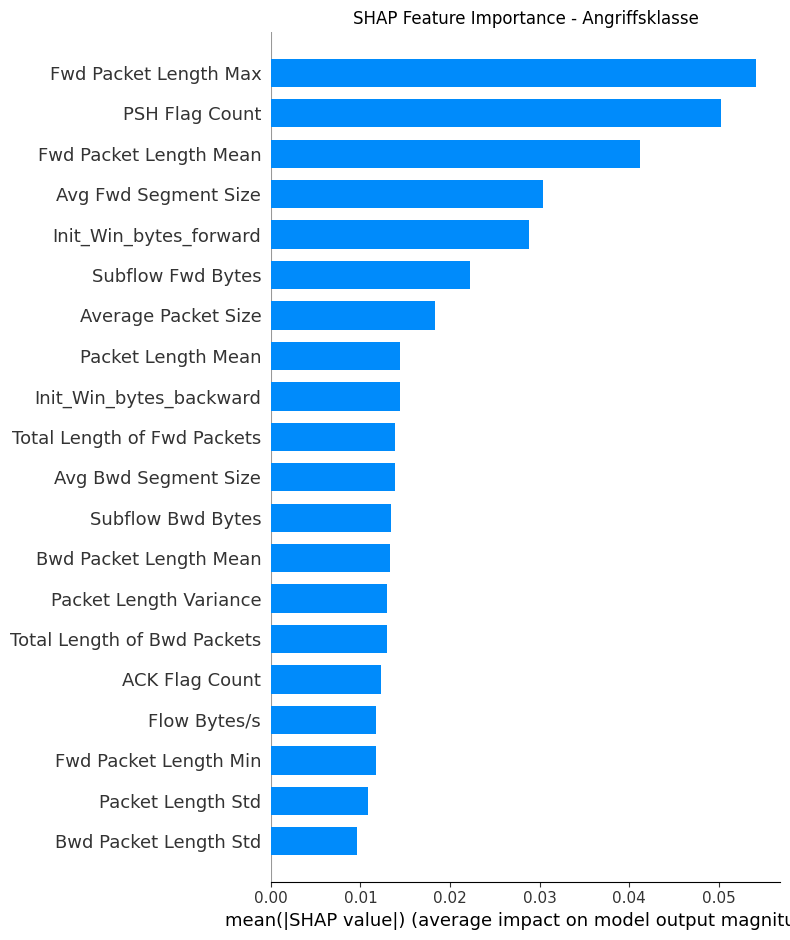

SHAP-Bar-Plot gespeichert unter: ..\outputs\figures\shap_bar_attack.png


In [11]:
plt.figure()
shap.summary_plot(
    shap_values_attack,
    X_test_sample,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance - Angriffsklasse")
plt.tight_layout()

output_file = FIGURE_OUTPUT_PATH / "shap_bar_attack.png"
plt.savefig(output_file, dpi=300, bbox_inches="tight")
plt.show()

print(f"SHAP-Bar-Plot gespeichert unter: {output_file}")

## SHAP Summary Plot

Der SHAP Summary Plot zeigt nicht nur, welche Merkmale wichtig sind, sondern auch, ob hohe oder niedrige Werte eines Merkmals die Entscheidung eher in Richtung Angriff oder normaler Traffic beeinflussen.

Damit wird die Modellentscheidung transparenter und besser interpretierbar.

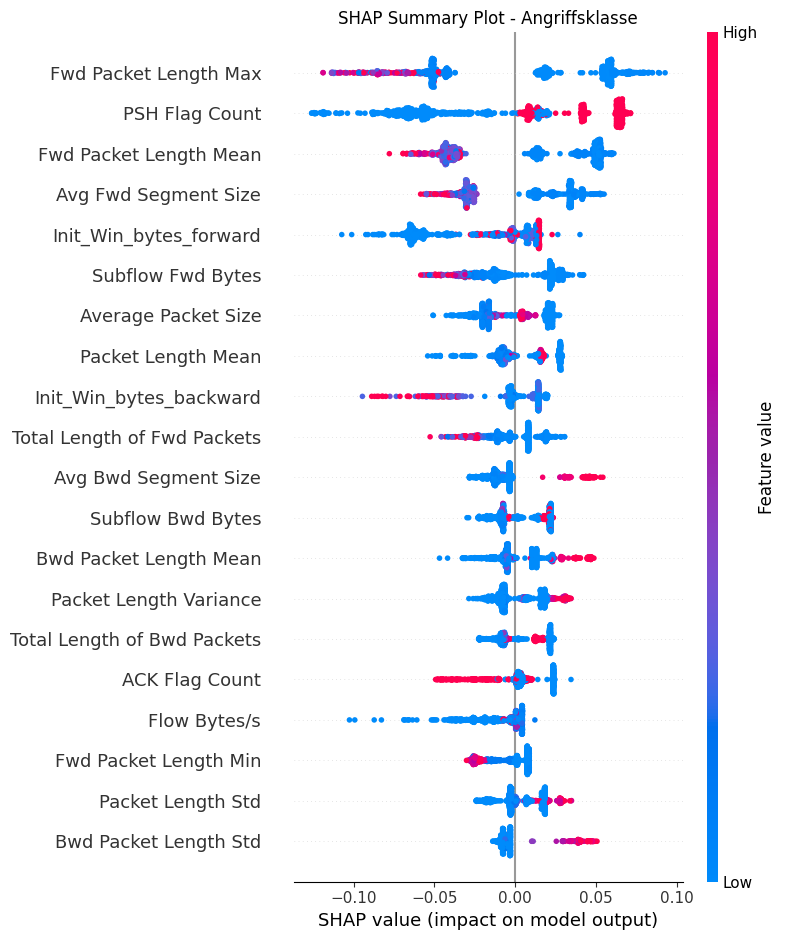

SHAP-Summary-Plot gespeichert unter: ..\outputs\figures\shap_summary_attack.png


In [12]:
plt.figure()
shap.summary_plot(
    shap_values_attack,
    X_test_sample,
    show=False
)

plt.title("SHAP Summary Plot - Angriffsklasse")
plt.tight_layout()

output_file = FIGURE_OUTPUT_PATH / "shap_summary_attack.png"
plt.savefig(output_file, dpi=300, bbox_inches="tight")
plt.show()

print(f"SHAP-Summary-Plot gespeichert unter: {output_file}")

## Lokale Erklärung einer einzelnen Modellentscheidung

Neben der globalen Analyse kann SHAP auch einzelne Vorhersagen erklären. Dadurch wird sichtbar, welche Netzwerkmerkmale bei einem konkreten Netzwerk-Flow zur Einstufung als Angriff beigetragen haben.

In [13]:
# Vorhersagen für die SHAP-Stichprobe
sample_predictions = rf_model.predict(X_test_sample)

# Index eines als Angriff klassifizierten Beispiels suchen
attack_indices = np.where(sample_predictions == 1)[0]

attack_index = attack_indices[0]

print("Ausgewählter Index in Stichprobe:", attack_index)
print("Modellvorhersage:", sample_predictions[attack_index])

Ausgewählter Index in Stichprobe: 6
Modellvorhersage: 1


## SHAP Waterfall Plot

Der Waterfall Plot erklärt eine einzelne Modellentscheidung. Er zeigt, welche Merkmale die Vorhersage in Richtung Angriff verschoben haben und welche Merkmale dagegen gewirkt haben.

Dadurch wird aus einer reinen Modellentscheidung eine nachvollziehbare Begründung.

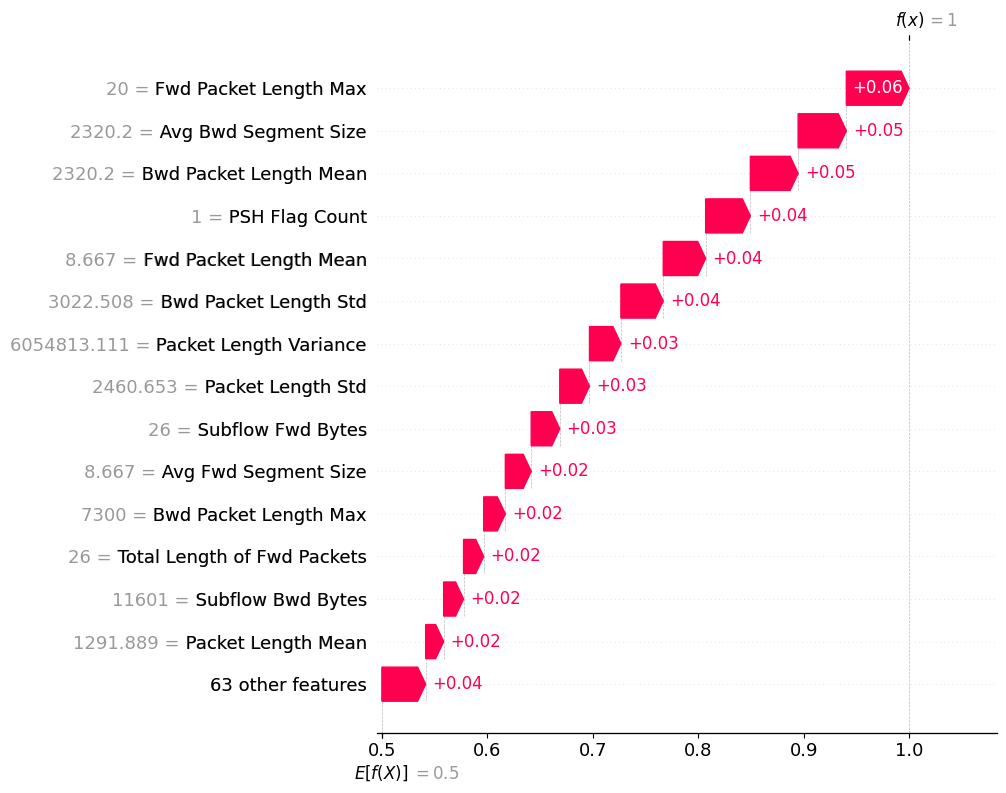

SHAP-Waterfall-Plot gespeichert unter: ..\outputs\figures\shap_waterfall_single_attack.png


In [14]:
# Erwartungswert für Angriffsklasse bestimmen
if isinstance(explainer.expected_value, list) or isinstance(explainer.expected_value, np.ndarray):
    expected_value_attack = explainer.expected_value[1]
else:
    expected_value_attack = explainer.expected_value

explanation = shap.Explanation(
    values=shap_values_attack[attack_index],
    base_values=expected_value_attack,
    data=X_test_sample.iloc[attack_index],
    feature_names=X_test_sample.columns
)

shap.waterfall_plot(explanation, max_display=15, show=False)

output_file = FIGURE_OUTPUT_PATH / "shap_waterfall_single_attack.png"
plt.savefig(output_file, dpi=300, bbox_inches="tight")
plt.show()

print(f"SHAP-Waterfall-Plot gespeichert unter: {output_file}")

## Zusammenfassung Explainable AI

In diesem Notebook wurde das trainierte Random-Forest-Modell mithilfe von Feature Importance und SHAP interpretiert. Die Feature Importance liefert eine globale Übersicht über die wichtigsten Netzwerkmerkmale. SHAP ergänzt diese Analyse, indem der konkrete Einfluss einzelner Merkmale auf die Modellentscheidung sichtbar gemacht wird.

Damit kann nicht nur gezeigt werden, dass das Modell Angriffe erkennt, sondern auch, welche Netzwerkmerkmale zur Einstufung als Angriff beigetragen haben. Dies reduziert die Black-Box-Problematik und erhöht die Nachvollziehbarkeit der KI-gestützten Cyberangriffserkennung.